### **Import libraries**

In [ ]:
import torch
from transformers import AutoModel
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

import shap
import lightgbm as lgb

In [107]:
import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import shap

from sklearn.metrics import precision_score, recall_score, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

### Load the preprocessed dataset

In [ ]:
# Load NSCLC gene expression dataset (GSE81089)
df = pd.read_csv("preprocessed_dataset.csv") 
labels = df["diagnosis"] # 1=squamous cell cancer, 2=AC unspecified, 3=Large cell/ NOS
gene_data = df.drop(columns=["sample_id","diagnosis","stage"])
# gene_data.columns = gene_data.columns.str.replace(r'[.]', '_', regex=True) # Rename columns to remove special characters

print("Data shape: ", gene_data.shape)
gene_data.head()

Data shape:  (199, 56685)


,TSPAN6,TNMD,DPM1,SCYL3,C1orf112,FGR,CFH,FUCA2,GCLC,NFYA,...,RP11-415F23.4,CYP2D6.2,SNORA28,Metazoa_SRP.33,GS1-166A23.1,XXbac-BPG252P9.9,XXbac-BPGBPG55C20.1,RP11-255P5.2,MIR4787,CTC-527H23.4
0,52.1950,0.230061,43.8616,14.71010,4.81335,7.40831,112.4260,43.9196,12.12890,13.3027,...,0.215946,0.0,0.0,0.0,0.0,1.38909,0.312571,0.086774,0.0,0.000000
1,37.8891,0.086034,47.0457,7.81233,5.92073,9.83188,39.7146,60.4056,9.20525,19.6343,...,0.583569,0.0,0.0,0.0,0.0,1.15011,0.050841,0.000000,0.0,0.000000
2,23.1910,0.048022,38.1292,12.31170,8.21385,9.68575,25.9596,49.0519,23.92220,20.1660,...,0.088140,0.0,0.0,0.0,0.0,1.11998,0.551958,0.036071,0.0,0.000000
3,25.0324,0.000000,54.3030,8.41631,6.71221,10.92630,80.2073,40.4700,46.93690,20.1807,...,1.150510,0.0,0.0,0.0,0.0,4.34570,0.319958,0.000000,0.0,0.086684
4,41.9686,2.570900,51.2969,8.84999,4.79088,8.36149,38.4429,58.1048,15.60820,23.3442,...,0.946770,0.0,0.0,0.0,0.0,2.61839,0.415423,0.041381,0.0,0.095240


**Extensional Preprocessing**

In [ ]:
import re

gene_data = gene_data.rename(columns = lambda x:re.sub('[^A-Za-z0-9_.]+', '__', x))


In [96]:
labels = df["diagnosis"] - 1

In [106]:
count_classes = df['diagnosis'].value_counts()
print(count_classes)

diagnosis
2    108
1     67
3     24
Name: count, dtype: int64


**Data Imbalance**

In [108]:
# Define your target labels
y = np.array([2] * 108 + [1] * 67 + [3] * 24)

# Compute class weights based on inverse frequency
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y), y=y)
print("Class weights:", dict(zip(np.unique(y), class_weights)))

Class weights: {np.int64(1): np.float64(0.9900497512437811), np.int64(2): np.float64(0.6141975308641975), np.int64(3): np.float64(2.763888888888889)}


### LightGBM

LightGBM (Light Gradient Boosting Machine) is an open-source gradient boosting framework developed by Microsoft. It is designed for efficiency and speed, particularly in handling large datasets with high-dimensional features. LightGBM is widely used for machine learning tasks, including classification, regression, and ranking.

Key Features of LightGBM:
1. Gradient-Based One-Side Sampling (GOSS) – Prioritizes important data points while reducing the size of the dataset, improving training efficiency.
2. Exclusive Feature Bundling (EFB) – Groups mutually exclusive features to reduce memory usage and speed up computation.
3. Histogram-Based Learning – Bins continuous features into discrete values, reducing computation complexity.
4. Efficient Handling of Large Datasets – Optimized for parallel and GPU processing.
5. Lower Memory Usage – Uses a more compact representation of data than other boosting frameworks like XGBoost.
6. Supports Categorical Features – Handles categorical variables natively without one-hot encoding.

Use Cases:
- Predictive modeling in finance (e.g., fraud detection, credit scoring)
- Recommendation systems
- Click-through rate (CTR) prediction in advertising
- Medical diagnosis and genomic analysis


In [118]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(gene_data, labels, test_size=0.2, random_state=42)

# Convert to LightGBM dataset
train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

In [ ]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

**Training**

<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

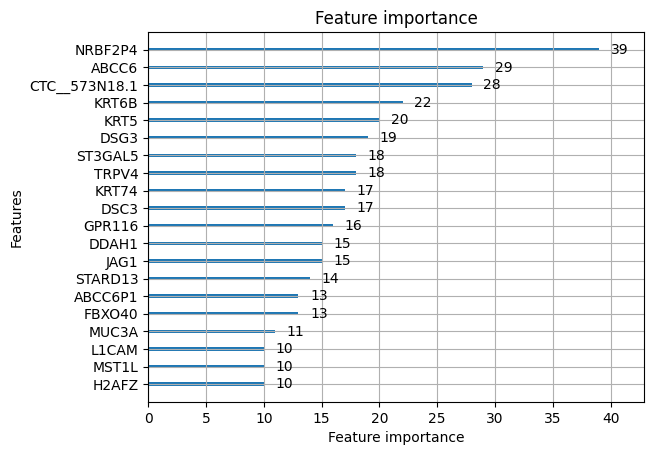

In [119]:
# Define parameters for LightGBM
params = {
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'max_depth': -1,
    'learning_rate': 0.05,
    'objective': 'multiclass',
    'num_class': 3,
    'class_weight': class_weights
}
    

# Train model
model = lgb.train(params, train_data, num_boost_round=100)

# Feature Importance
lgb.plot_importance(model, max_num_features=20)

**Shap Interpretation**

ref: Lundberg, S. M., & Lee, S.-I. (2017). A unified approach to interpreting model predictions. In I. Guyon, U. V. Luxburg, S. Bengio, H. Wallach, R. Fergus, S. Vishwanathan, & R. Garnett (Eds.), *Advances in neural information processing systems 30* (pp. 4765–4774). Curran Associates, Inc. [Paper link](http://papers.nips.cc/paper/7062-a-unified-approach-to-interpreting-model-predictions.pdf)

<Figure size 640x480 with 0 Axes>

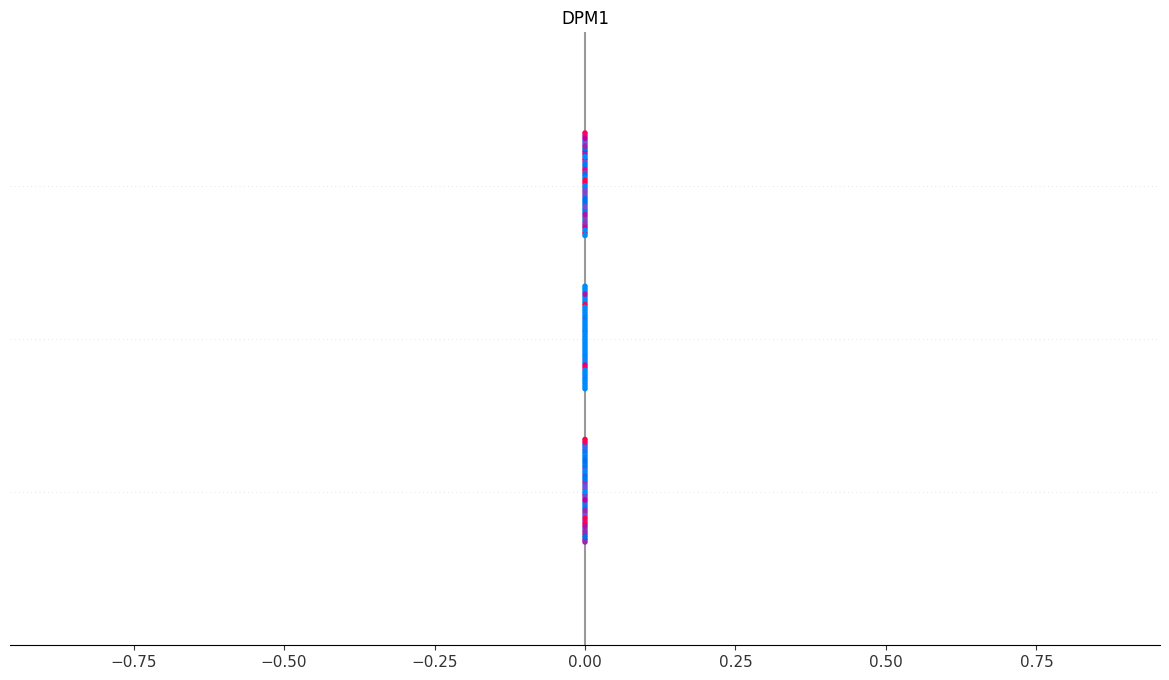

In [120]:
# SHAP explanation
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Summary plot
shap.summary_plot(shap_values, X_test, class_names=["Squamous Cell", "AC Unspecified", "Large Cell/NOS"])

**Evaluation**

Precision per class: [1.         0.78571429 0.        ]
Recall per class: [0.84615385 0.95652174 0.        ]


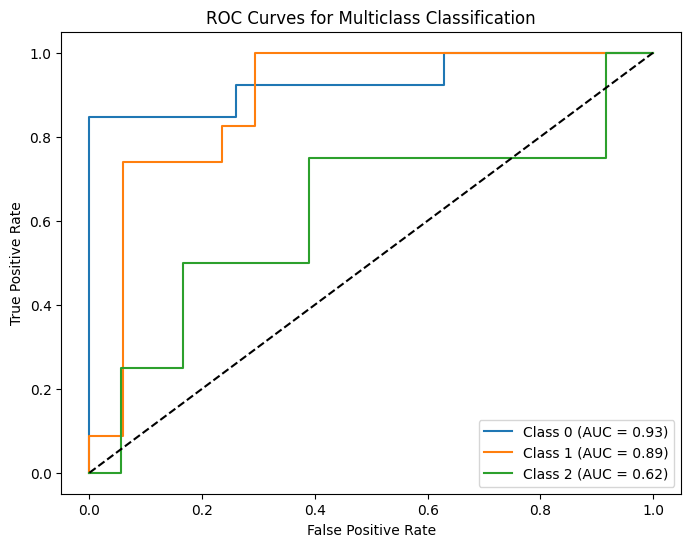

In [121]:
# Convert probabilities to predicted classes
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Get the predicted class

# Precision & Recall
precision = precision_score(y_test, y_pred_classes, average=None)  # Per-class precision
recall = recall_score(y_test, y_pred_classes, average=None)  # Per-class recall

print("Precision per class:", precision)
print("Recall per class:", recall)

# Binarize labels for ROC computation (One-vs-Rest strategy)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])  # Modify class labels accordingly
n_classes = y_test_bin.shape[1]

# Compute ROC curve and ROC AUC
fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], "k--")  # Diagonal line for reference
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Multiclass Classification")
plt.legend(loc="lower right")
plt.show()

### Tokenization and Feature Extraction Using Geneformer
ref: https://huggingface.co/dmis-lab/biobert-v1.1

In [5]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("dmis-lab/biobert-v1.1")
model = AutoModel.from_pretrained("dmis-lab/biobert-v1.1")

# Tokenize the gene expression data (text format)
inputs = tokenizer(gene_texts, return_tensors="pt", padding=True, truncation=True)

# Pass the data through BioBERT to get embeddings
with torch.no_grad():
    outputs = model(**inputs)

# Use mean pooling of the last hidden state for embeddings
embeddings = outputs.last_hidden_state.mean(dim=1)

# Now, `embeddings` contains a vector representation for each sample
print(embeddings.shape)

torch.Size([199, 768])


### Identify Oncogenes Using Geneformer Embeddings

Step 1: Prepare Oncogene Data

ref: 
- El-Telbany A, Ma PC. Cancer genes in lung cancer: racial disparities: are there any? Genes Cancer. 2012 Jul;3(7-8):467-80. doi: 10.1177/1947601912465177. PMID: 23264847; PMCID: PMC3527990. https://pmc.ncbi.nlm.nih.gov/articles/PMC3527990/#section2-1947601912465177

In [7]:
# List of known oncogenes
oncogenes = ["EGFR", "KRAS", "MET", "LKB1", "BRAF", "PIK3CA", "ALK", "RET", "ROS1"]

Step 2: Extract Geneformer Embeddings

Get label genes as oncogenes (1) or non-oncogenes (0)

In [25]:
# Assuming embeddings were extracted and stored in `embeddings`
# Let's link them to the oncogene labels
# cols = df.columns[3:]
# labels = [ 1 if gene in oncogenes else 0 for gene in cols]
labels = df.columns[gene_texts.isin(oncogenes)].map(lambda gene: 1 if gene in oncogenes else 0)

# Check the shape of the embeddings and labels
print(embeddings.shape, len(labels))

AttributeError: 'list' object has no attribute 'isin'

In [ ]:

cols

Index(['TSPAN6', 'TNMD', 'DPM1', 'SCYL3', 'C1orf112', 'FGR', 'CFH', 'FUCA2',
       'GCLC', 'NFYA',
       ...
       'RP11-415F23.4', 'CYP2D6.2', 'SNORA28', 'Metazoa_SRP.33',
       'GS1-166A23.1', 'XXbac-BPG252P9.9', 'XXbac-BPGBPG55C20.1',
       'RP11-255P5.2', 'MIR4787', 'CTC-527H23.4'],
      dtype='object', length=56685)

In [ ]:

1 in labels

True

Step 3: Train a Classifier

Use the embeddings to train a classifier to predict whether a gene is an oncogene or not

In [ ]:
# Assuming embeddings and labels are aligned
X_train, X_test, y_train, y_test = train_test_split(embeddings.numpy(), labels, test_size=0.2, random_state=42)

# Train a Random Forest classifier
clf = RandomForestClassifier(n_estimators=100)
clf.fit(X_train, y_train)

# Make predictions
y_pred = clf.predict(X_test)

# Evaluate model performance
print("Accuracy:", accuracy_score(y_test, y_pred))

Step 4: Evaluate and Interpret Results

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get probabilities for the positive class
y_prob = clf.predict_proba(X_test)[:, 1]

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()
